# Кейс 5. Entity Resolution для ClearPic
## Часть 1 - разведочный анализ и методология оценки

Задача: найти и объединить дубликаты записей о физических и юридических лицах в базе на 6 стран и 3 алфавита, обеспечить поиск по базе.

1. Структура данных
2. Справочные поля и перекосы
3. Мультиязычность
4. Gold-разметка
5. Сложность дублей
6. Cross-country дубли
7. Методология оценки

## 0. Подготовка

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import config as cfg
from normalize import normalize, translit, script_label_for_series

plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

def human(n):
    "Разделитель разрядов - чтобы миллионы читались глазами."
    return f"{n:,}".replace(",", " ")

Читаем датасет целиком.

In [2]:
df = pd.read_parquet(cfg.DATA)
print("строк:  ", human(len(df)))
print("колонок:", df.shape[1])
print("память: ", f"{df.memory_usage(deep=True).sum() / 1024**3:.2f} ГБ")

строк:   3 733 247
колонок: 11
память:  1.04 ГБ


## 1. Структура данных

Строка - связь «компания - субъект» (директор, владелец, бенефициар). Резолвится сторона субъекта (`party`); компания и роль - контекст.

In [3]:
info = pd.DataFrame({
    "тип": df.dtypes.astype(str),
    "пропуски": df.isna().mean(),
    "уникальных": df.nunique(),
})
info["пропуски"] = (info["пропуски"] * 100).round(1).astype(str) + "%"
info

,тип,пропуски,уникальных
record_id,str,0.0%,3418423
country,str,0.0%,6
source_snapshot_date,str,0.0%,5605
relation_kind,str,0.0%,3
relation_role,str,0.0%,67
party_type,str,0.0%,3
company_public_id,str,1.5%,1430366
company_name_norm,str,8.3%,1182617
party_public_id,str,97.0%,53427
party_name,str,0.0%,1932720


- `party_name` заполнен на 100% - основное поле матчинга.
- `party_public_id` заполнен на 3% - gold-разметка.
- `company_public_id` - внешний ключ на компанию, не разметка дубликатов.
- `ownership_share_pct` пропущен на 92%.

## 2. Справочные поля и перекосы

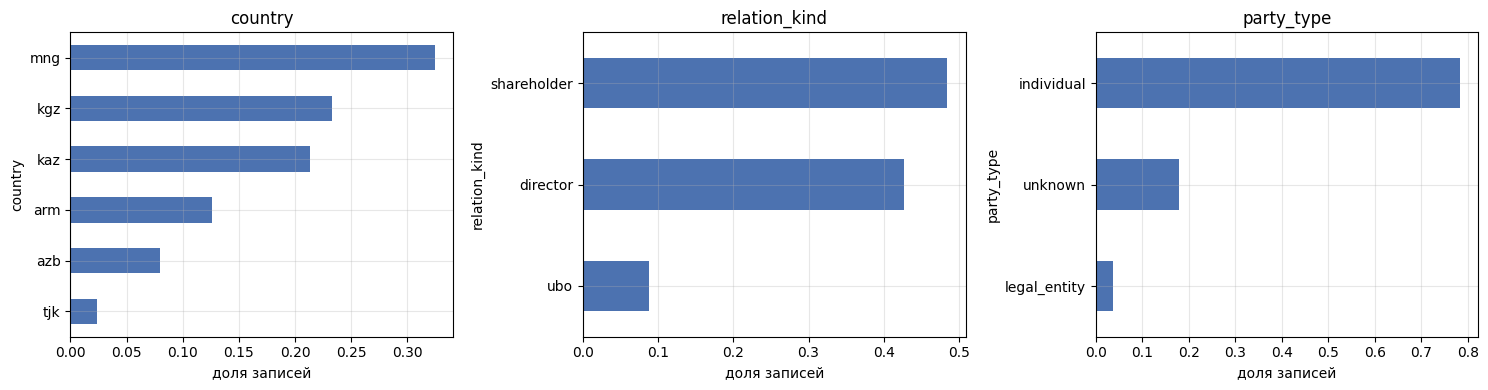


country: три крупнейшие категории = 77.0% базы

relation_kind: три крупнейшие категории = 100.0% базы

party_type: три крупнейшие категории = 100.0% базы


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, [cfg.COL_COUNTRY, cfg.COL_REL_KIND, cfg.COL_PARTY_TYPE]):
    vc = df[col].value_counts(normalize=True)
    vc.sort_values().plot.barh(ax=ax, color="#4C72B0")
    ax.set_title(col)
    ax.set_xlabel("доля записей")
plt.tight_layout()
plt.show()

for col in [cfg.COL_COUNTRY, cfg.COL_REL_KIND, cfg.COL_PARTY_TYPE]:
    vc = df[col].value_counts(normalize=True)
    print(f"\n{col}: три крупнейшие категории = {vc.head(3).sum():.1%} базы")

Три страны дают 77% базы -> сплит стратифицируем по стране и типу субъекта.

## 3. Мультиязычность

Алфавит определяем по диапазонам Unicode; записи с несколькими алфавитами помечаем `mixed`.

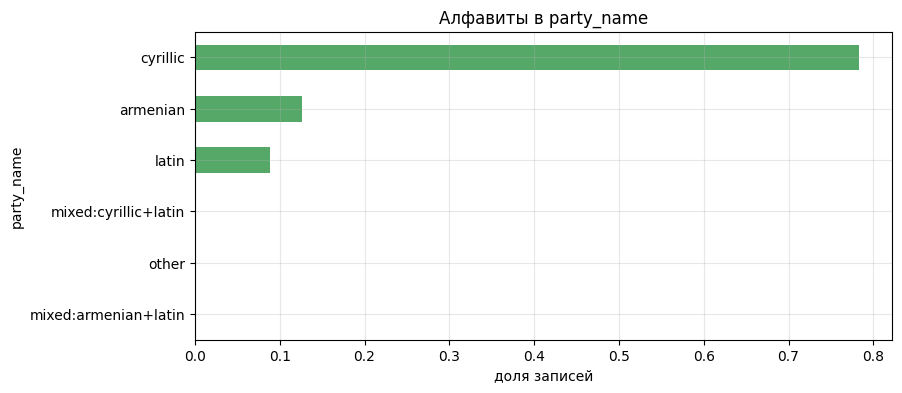

party_name
cyrillic                0.783358
armenian                0.126582
latin                   0.088470
mixed:cyrillic+latin    0.001437
other                   0.000102
mixed:armenian+latin    0.000050


In [5]:
names = df[cfg.COL_NAME].dropna().astype(str)
sample = names.sample(min(400_000, len(names)), random_state=cfg.RANDOM_STATE)

scripts = script_label_for_series(sample)
dist = scripts.value_counts(normalize=True)

dist.head(8).sort_values().plot.barh(color="#55A868")
plt.title("Алфавиты в party_name")
plt.xlabel("доля записей")
plt.show()

print(dist.head(8).to_string())

Отдельно - расширенная кириллица казахского, киргизского, монгольского и таджикского (`ә ғ қ ң ө ұ ү һ і ў ҳ ҷ`).

In [6]:
import re
EXTRA_CYR = re.compile(r"[ѐ-ԯӐ-ӿ]")

share_party = sample.str.contains(EXTRA_CYR).mean()
comp = df[cfg.COL_COMPANY_NAME].dropna().astype(str)
comp_s = comp.sample(min(400_000, len(comp)), random_state=cfg.RANDOM_STATE)
share_comp = comp_s.str.contains(EXTRA_CYR).mean()

print(f"нестандартная кириллица в party_name:        {share_party:.1%}")
print(f"нестандартная кириллица в company_name_norm: {share_comp:.1%}")

нестандартная кириллица в party_name:        17.7%
нестандартная кириллица в company_name_norm: 37.5%


Треть названий компаний содержит буквы вне русской кириллицы - транслитерация обязательна.

## 4. Gold-разметка

`party_public_id` заполнен у 3% записей; записи с одинаковым значением - одна сущность.

In [7]:
gold = df[df[cfg.COL_GOLD].notna()]
sizes = gold.groupby(cfg.COL_GOLD).size()
multi = sizes[sizes > 1]

print(f"размечено записей:        {human(len(gold))}  ({len(gold)/len(df):.2%} базы)")
print(f"уникальных сущностей:     {human(sizes.shape[0])}")
print(f"сущностей с 2+ записями:  {human(multi.shape[0])}  ({multi.shape[0]/sizes.shape[0]:.1%})")
print(f"записей внутри дублей:    {human(int(multi.sum()))}")
print()
for q in (0.5, 0.9, 0.95, 0.99, 0.999):
    print(f"  размер кластера p{q*100:<6g} {int(sizes.quantile(q))}")
print(f"  размер кластера max     {human(int(sizes.max()))}")

размечено записей:        112 141  (3.00% базы)
уникальных сущностей:     53 427
сущностей с 2+ записями:  24 697  (46.2%)
записей внутри дублей:    83 411

  размер кластера p50     1
  размер кластера p90     3
  размер кластера p95     3
  размер кластера p99     5
  размер кластера p99.9   10
  размер кластера max     13 783


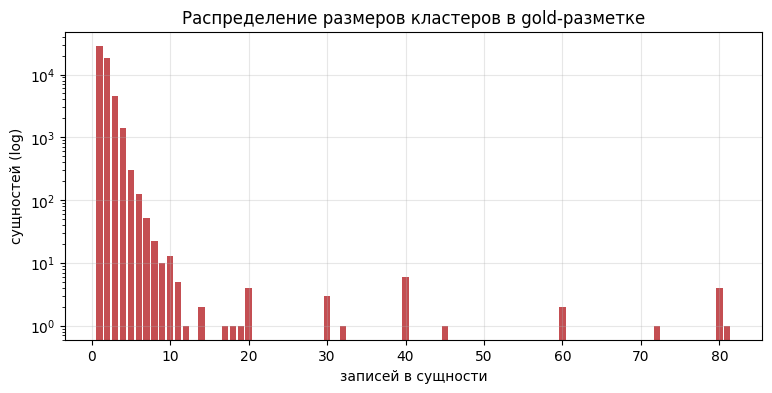

In [8]:
counts = sizes.value_counts().sort_index()
plt.bar(counts.index[:25], counts.values[:25], color="#C44E52")
plt.yscale("log")
plt.title("Распределение размеров кластеров в gold-разметке")
plt.xlabel("записей в сущности")
plt.ylabel("сущностей (log)")
plt.show()

### Экстремальный кластер

Кластер размера *k* даёт *k·(k-1)/2* позитивных пар.

In [9]:
pairs_all = int((sizes * (sizes - 1) // 2).sum())
top = int(sizes.max())
pairs_top = top * (top - 1) // 2

print(f"позитивных пар без ограничения:      {human(pairs_all)}")
print(f"из них даёт крупнейший кластер:      {human(pairs_top)}  ({pairs_top/pairs_all:.1%})")

capped = int(np.minimum(sizes * (sizes - 1) // 2, 100).sum())
print(f"с ограничением 100 пар на сущность:  {human(capped)}")
print(f"сокращение:                          в {pairs_all/max(capped,1):.0f} раз")

позитивных пар без ограничения:      101 551 746
из них даёт крупнейший кластер:      94 978 653  (93.5%)
с ограничением 100 пар на сущность:  52 661
сокращение:                          в 1928 раз


Один кластер даёт 93,5% всех пар. Вводим ограничение: не более 100 пар на сущность.

## 5. Сложность дублей

Какая доля дублей решается точным совпадением после нормализации, а какая требует матчинга.

In [10]:
g = gold[gold[cfg.COL_GOLD].isin(multi.index)].copy()
g["key"] = g[cfg.COL_NAME].astype(str).map(lambda s: normalize(s))

variants = g.groupby(cfg.COL_GOLD)["key"].nunique()
identical = (variants == 1).mean()

print(f"кластеров с 2+ записями:                    {human(len(variants))}")
print(f"из них все написания идентичны:             {identical:.1%}")
print(f"из них есть 2+ различных написания:         {1-identical:.1%}")

кластеров с 2+ записями:                    24 697
из них все написания идентичны:             100.0%
из них есть 2+ различных написания:         0.0%


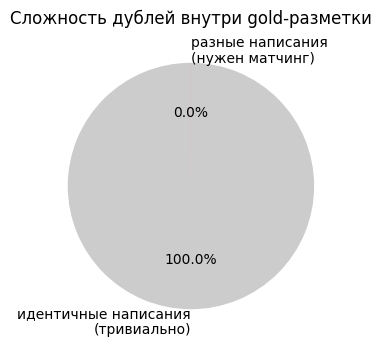

In [11]:
plt.pie([identical, 1 - identical],
        labels=["идентичные написания\n(тривиально)",
                "разные написания\n(нужен матчинг)"],
        autopct="%1.1f%%", colors=["#CCCCCC", "#DD8452"], startangle=90)
plt.title("Сложность дублей внутри gold-разметки")
plt.ylabel("")
plt.show()

## 6. Cross-country дубли

В `summary.json`: `person_overlap_targets = 3693`, `company_overlap_targets = 182` - сущности, встречающиеся более чем в одной стране. Проверяем, покрывает ли их разметка.

In [12]:
spans = gold.groupby(cfg.COL_GOLD)[cfg.COL_COUNTRY].nunique()
print(f"идентификаторов в разметке:   {human(len(spans))}")
print(f"охватывают 2+ страны:         {human(int((spans > 1).sum()))}")

идентификаторов в разметке:   53 427
охватывают 2+ страны:         0


### Ноль

Ни один идентификатор не встречается более чем в одной стране: surrogate key строится внутри страны (README датасета). Следовательно, gold содержит только внутристрановые дубли, cross-country в ней не размечен, и метрики на gold завышены по построению.

Проверим, что даёт точное совпадение имени после нормализации и транслитерации между странами.

In [13]:
def cross_country_keys(frame, value_col):
    "Сколько нормализованных значений встречается в 2+ странах."
    s = frame[value_col].dropna().astype(str)
    cache = {v: translit(normalize(v)) for v in s.unique()}
    key = s.map(cache)
    tab = pd.DataFrame({"k": key.values,
                        "c": frame.loc[key.index, cfg.COL_COUNTRY].values})
    tab = tab[tab.k.str.len() > 0]
    per = tab.groupby("k")["c"].nunique()
    return per[per > 1]

ind = df[df[cfg.COL_PARTY_TYPE] == "individual"]
m_person = cross_country_keys(ind, cfg.COL_NAME)

comp_df = df[df[cfg.COL_COMPANY_NAME].notna()]
m_comp = cross_country_keys(comp_df, cfg.COL_COMPANY_NAME)

res = pd.DataFrame({
    "найдено точным совпадением": [len(m_person), len(m_comp)],
    "заложено в summary.json":    [3693, 182],
}, index=["физлица", "компании"])
res["отношение"] = (res.iloc[:, 0] / res.iloc[:, 1]).round(2)
res

,найдено точным совпадением,заложено в summary.json,отношение
физлица,3355,3693,0.91
компании,681,182,3.74


Физлица: 3 355 против 3 693 - тот же порядок; остаток около 340 - случаи с разошедшимся написанием. Часть найденных - однофамильцы, поэтому это оценка порядка, а не recall.

Компании: 681 против 182 - ложные срабатывания на типовых названиях; для компаний одного названия недостаточно.

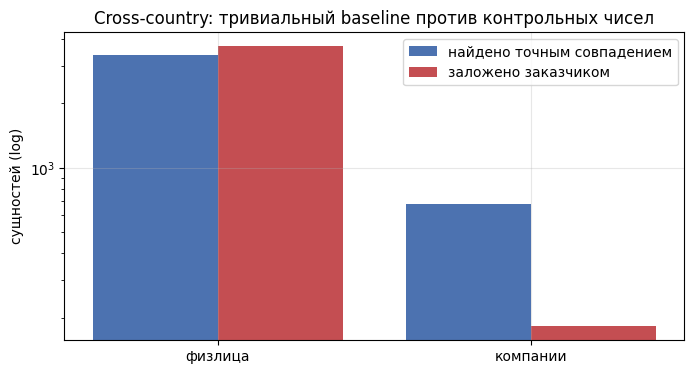

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(2)
ax.bar(x - 0.2, res.iloc[:, 0], 0.4, label="найдено точным совпадением", color="#4C72B0")
ax.bar(x + 0.2, res.iloc[:, 1], 0.4, label="заложено заказчиком", color="#C44E52")
ax.set_xticks(x); ax.set_xticklabels(res.index)
ax.set_yscale("log"); ax.set_ylabel("сущностей (log)")
ax.set_title("Cross-country: тривиальный baseline против контрольных чисел")
ax.legend()
plt.show()

## 7. Методология оценки

| | набор A - внутристрановой | набор B - cross-country |
|---|---|---|
| источник меток | `party_public_id` | меток нет |
| что измеряем | precision, recall, F1, ROC-AUC | число найденных сущностей |
| контроль | отложенная выборка | сверка с 3693 и 182 |
| сложность | ниже: часть дублей тривиальна | выше: разные алфавиты и написания |

Набор A: позитивы - записи с одинаковым `party_public_id`, не более 100 на сущность; негативы - часть 2. Сплит стратифицированный, по сущностям, а не по парам.

Набор B: меток нет, используется для калибровки порога по контрольным числам.

Метрики отчитываются раздельно по A и B, плюс по сложному подмножеству A, где написания внутри кластера различаются.

## Итоги части 1

- 3,73 млн строк, 6 стран, 3 алфавита; строка - связь «компания - субъект».
- Перекос по странам -> стратифицированный сплит.
- Треть названий с расширенной кириллицей -> транслитерация обязательна.
- Gold-разметка у 3% записей; один кластер даёт 93,5% пар -> ограничение вклада сущности.
- Gold покрывает только внутристрановые дубли -> два тестовых набора.